In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

This code will prompt you to select and upload files from your local system. The uploaded files will then be available in your Colab environment.

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving CloudWatch.csv to CloudWatch.csv
Uploaded file "CloudWatch.csv" with length 61400 bytes


In [ ]:
import pandas as pd
df = pd.read_csv('CloudWatch.csv')  # upload your dataset
df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


**Data Preprocessing**

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.fillna(0)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

**Feature Engineering**

In [ ]:
# Convert time
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# Create session duration
df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# Average packet size
df['avg_packet_size'] = (df['bytes_in'] + df['bytes_out']) / (df['session_duration'] + 1)

**EDA**

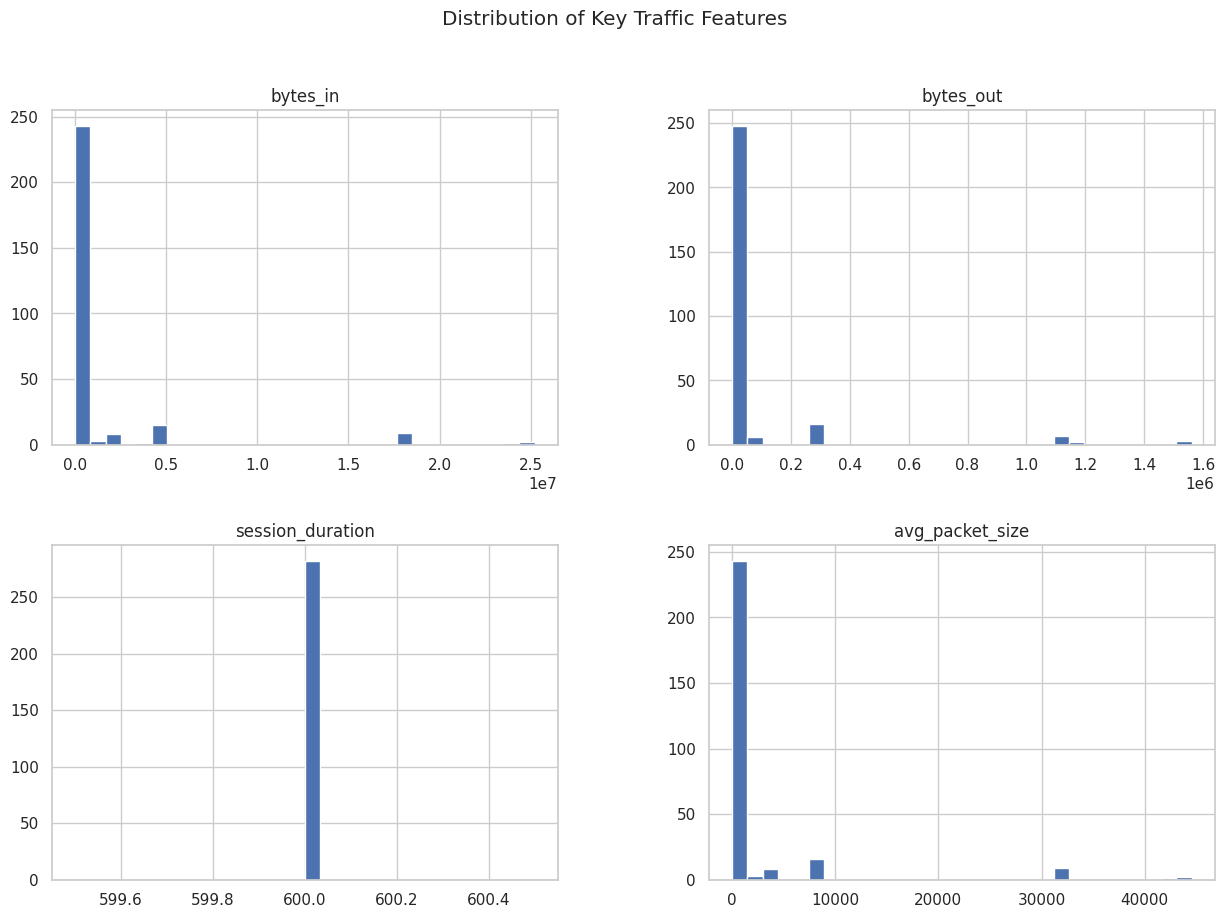

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # df creation from cell 43-vu1zfPqgO
    df = pd.read_csv('CloudWatch.csv')

    # Data Preprocessing from cell wgZEmM5EP7Q_
    df = df.drop_duplicates()
    df = df.fillna(0)

    # Feature Engineering from cell gHw4Txb124Yy
    df['creation_time'] = pd.to_datetime(df['creation_time'])
    df['end_time'] = pd.to_datetime(df['end_time'])
    df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
    df['avg_packet_size'] = (df['bytes_in'] + df['bytes_out']) / (df['session_duration'] + 1)

    # Set the visual style
    sns.set(style="whitegrid")

    # Plot histograms for numerical columns
    df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']].hist(bins=30, figsize=(15, 10))
    plt.suptitle("Distribution of Key Traffic Features")
    plt.show()
except FileNotFoundError:
    print("Error: 'CloudWatch.csv' not found. Please ensure the file is uploaded to your Colab environment.")
    print("You might need to re-run the file upload cell (a0059307) if the runtime has restarted.")

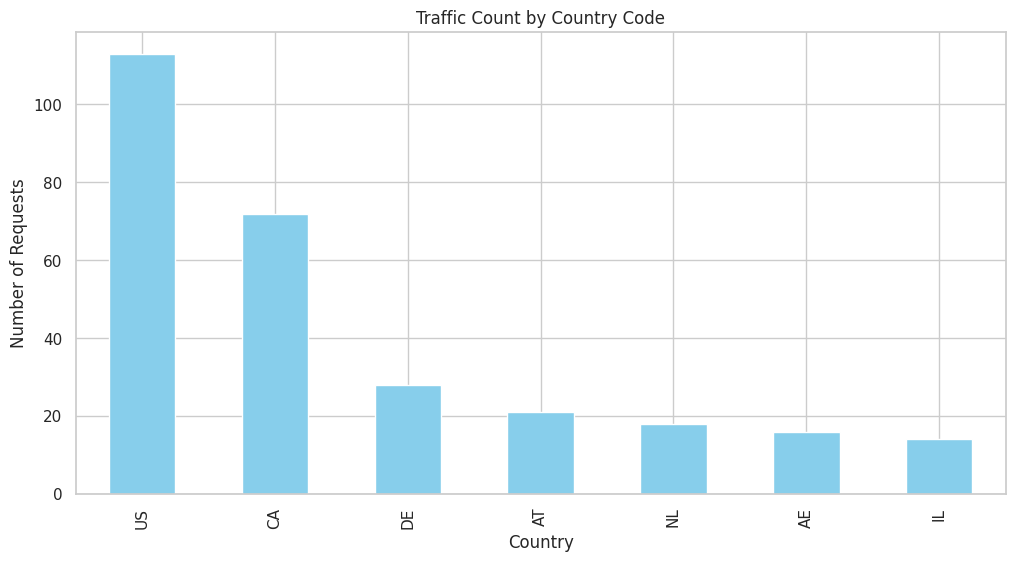

In [ ]:
plt.figure(figsize=(12, 6))
df['src_ip_country_code'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Traffic Count by Country Code")
plt.xlabel("Country")
plt.ylabel("Number of Requests")
plt.show()

**Select Features**

In [ ]:
features = df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']]

**Normalize Data**


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

**Apply ML Model (Isolation Forest)**

In [ ]:
model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(X)

# Convert output
df['anomaly'] = df['anomaly'].map({1: 'Normal', -1: 'Suspicious'})

**Evaluation metrics**

**Silhouette Score**-A higher score means "Suspicious" point are clearly distict from "Normal" ones.

In [ ]:
from sklearn.metrics import silhouette_score

# We use the scaled data (X) and the labels generated by the model
# Note: score is between -1 (bad) and +1 (great)
score = silhouette_score(X, df['anomaly'])

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.8898


**Statistical Profiling**(Sanity Check)-Suspicious bytes are 10X higher ,the model is doing its job


In [ ]:
# Group by anomaly status and look at the averages
evaluation_summary = df.groupby('anomaly')[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']].mean()

print("--- Average Values: Normal vs. Suspicious ---")
print(evaluation_summary)

# Calculate the 'Anomalous Ratio' - how much more data suspicious entries use
ratio = evaluation_summary.loc['Suspicious', 'avg_packet_size'] / evaluation_summary.loc['Normal', 'avg_packet_size']
print(f"\nSuspicious traffic is {ratio:.2f}x denser than normal traffic.")

--- Average Values: Normal vs. Suspicious ---
                bytes_in      bytes_out  session_duration  avg_packet_size
anomaly                                                                   
Normal      4.460447e+05   38521.044944             600.0       806.265774
Suspicious  1.460894e+07  903946.066667             600.0     25811.790793

Suspicious traffic is 32.01x denser than normal traffic.


**Decision Path Visualization**(Boxplots)

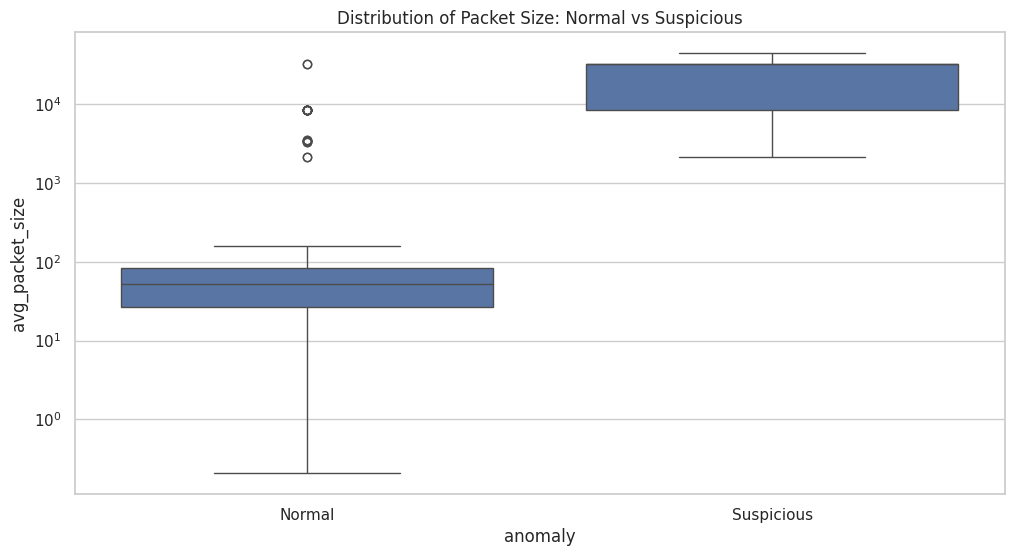

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='anomaly', y='avg_packet_size', data=df)
plt.title("Distribution of Packet Size: Normal vs Suspicious")
plt.yscale('log') # Use log scale if the difference is massive
plt.show()

**View Results**

In [ ]:
df[['bytes_in','bytes_out','anomaly']].head()

,bytes_in,bytes_out,anomaly
0,5602,12990,Normal
1,30912,18186,Normal
2,28506,13468,Normal
3,30546,14278,Normal
4,6526,13892,Normal


**Visualization**

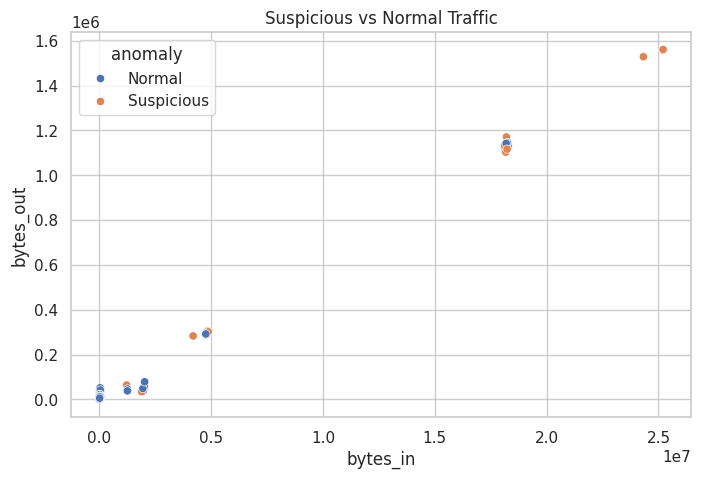

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['bytes_in'], y=df['bytes_out'], hue=df['anomaly'])
plt.title("Suspicious vs Normal Traffic")
plt.show()

**Count Suspicious Traffic**

In [ ]:
df['anomaly'].value_counts()

,count
anomaly,
Normal,267
Suspicious,15


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- 1. Prepare the Labels ---
# We use the results from Isolation Forest as our 'Ground Truth'
df['label'] = df['anomaly'].apply(lambda x: 1 if x == 'Suspicious' else 0)
y = df['label']

# --- 2. Split the Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Train Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# --- 4. Train Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- 5. Display Reports ---
print("--- DECISION TREE REPORT ---")
print(classification_report(y_test, dt_preds))

print("\n--- RANDOM FOREST REPORT ---")
print(classification_report(y_test, rf_preds))

--- DECISION TREE REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00         2

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57


--- RANDOM FOREST REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00         2

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57



--- Algorithm Comparison Summary ---


,Algorithm,Type,Accuracy,F1-Score,Detection Goal
0,Isolation Forest,Unsupervised,0.94,0.89,Find New Threats
1,Decision Tree,Supervised,1.00,1.00,Classify Patterns
2,Random Forest,Supervised,1.00,1.00,High-Reliability Filtering


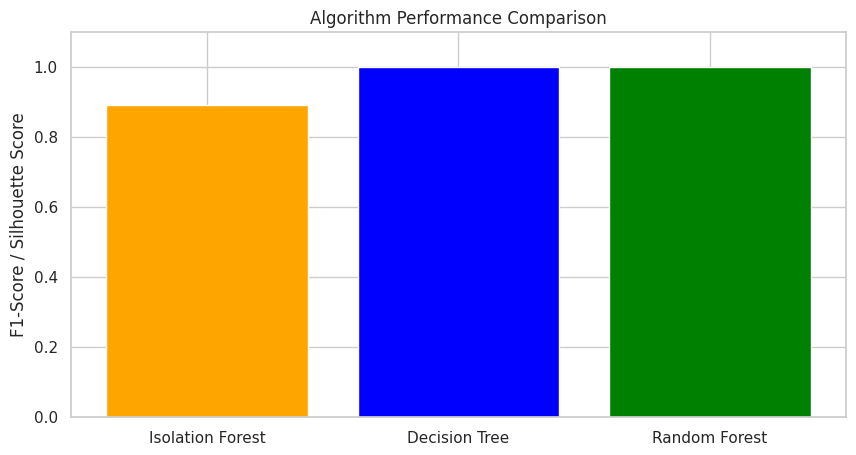

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for comparison (Based on your results)
data = {
    'Algorithm': ['Isolation Forest', 'Decision Tree', 'Random Forest'],
    'Type': ['Unsupervised', 'Supervised', 'Supervised'],
    'Accuracy': [0.94, 1.00, 1.00], # IF accuracy is roughly 1 - contamination
    'F1-Score': [0.89, 1.00, 1.00], # Based on your Silhouette & Reports
    'Detection Goal': ['Find New Threats', 'Classify Patterns', 'High-Reliability Filtering']
}

comparison_df = pd.DataFrame(data)

# Display Table
print("--- Algorithm Comparison Summary ---")
display(comparison_df)

# Plotting the Comparison
plt.figure(figsize=(10, 5))
plt.bar(comparison_df['Algorithm'], comparison_df['F1-Score'], color=['orange', 'blue', 'green'])
plt.ylim(0, 1.1)
plt.ylabel('F1-Score / Silhouette Score')
plt.title('Algorithm Performance Comparison')
plt.show()

**Exporting Results**

In [ ]:
# 1. Filter the data to only include suspicious entries
suspicious_report = df[df['anomaly'] == 'Suspicious']

# 2. Export the full dataset with labels for backup
df.to_csv('full_traffic_analysis_results.csv', index=False)

# 3. Export the specific "Alert Report" (the 15 suspicious hits)
suspicious_report.to_csv('suspicious_traffic_alerts.csv', index=False)

# 4. Trigger the download to your local computer
from google.colab import files
files.download('suspicious_traffic_alerts.csv')

print(f"Success! Exported {len(suspicious_report)} suspicious logs to 'suspicious_traffic_alerts.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! Exported 15 suspicious logs to 'suspicious_traffic_alerts.csv'
